# Superstore Sales Analytics & Operational Forecasting Pipeline

**Project Context**: This notebook implements the end-to-end exploratory data analysis, time series forecasting, anomaly isolation, and product demand clustering models for the Superstore Sales dataset. The outputs are saved in serialized pickle binaries to power the operational Streamlit dashboard.

In [ ]:
from logging import warn

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("train.csv")
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [ ]:
df.info()  ## Information about the dataset, including the number of non-null values and data types.

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [ ]:
df.describe()  ## Statistical summary of the dataset, including count, mean, standard deviation, min, max, and quartiles for numerical columns.

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

As we can see only postal code contain null values (11)

In [ ]:
df.shape

(9800, 18)

In [ ]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [ ]:
## Making dataframe of dates to extract features from dates
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y"
)

In [ ]:
df.duplicated().sum()  ## checking for duplicates

np.int64(0)

No duplicates records are found

In [ ]:
### Year
df["Year"] = df["Order Date"].dt.year

### Month Number
df["Month"] = df["Order Date"].dt.month

### Month Name
df["Month Name"] = df["Order Date"].dt.month_name()

### Week Number
df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)

### Day of Week
df["Day of Week"] = df["Order Date"].dt.day_name()

### Quarter
df["Quarter"] = df["Order Date"].dt.quarter

In [ ]:
### making a function to get season from month number
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [ ]:
### Calculating the number of shipping days by subtracting the order date from the ship date and converting the result to days.
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [ ]:
### Calculating the daily sales by grouping the data by order date and summing the sales for each day. The result is reset to a new dataframe with the order date and total sales for that day.
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

In [ ]:
### Calculating the weekly sales by grouping the data by order date and summing the sales for each week. The result is reset to a new dataframe with the order date and total sales for that week.
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

In [ ]:
### Calculating the monthly sales by grouping the data by order date and summing the sales for each month. The result is reset to a new dataframe with the order date and total sales for that month.
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

In [ ]:
### Calculating the sales by category by grouping the data by category and summing the sales for each category. The result is sorted in descending order.
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

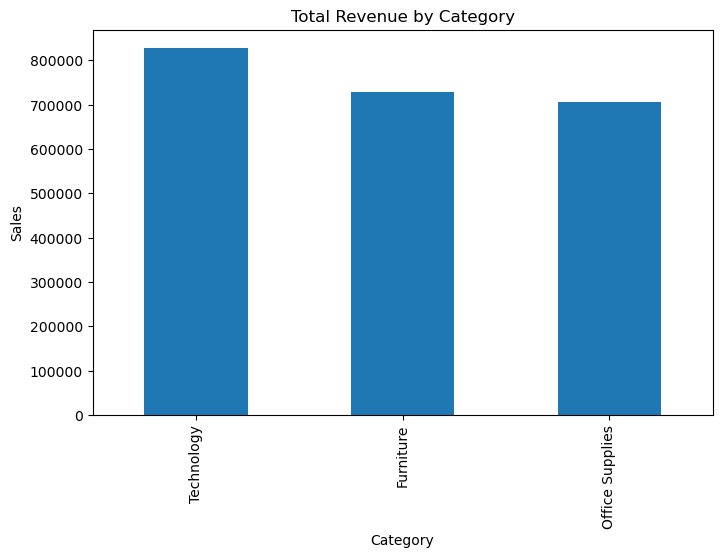

In [ ]:
### Plotting the sales by category
category_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Revenue by Category")
plt.ylabel("Sales")
plt.show()

Technology had made the best revenue

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month Name,Week,Day of Week,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn,7


In [ ]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Year',
 'Month',
 'Month Name',
 'Week',
 'Day of Week',
 'Quarter',
 'Season',
 'Shipping Days']

In [ ]:
### Calculating the yearly sales growth by region by grouping the data by year and region and summing the sales

region_yearly_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

region_yearly_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


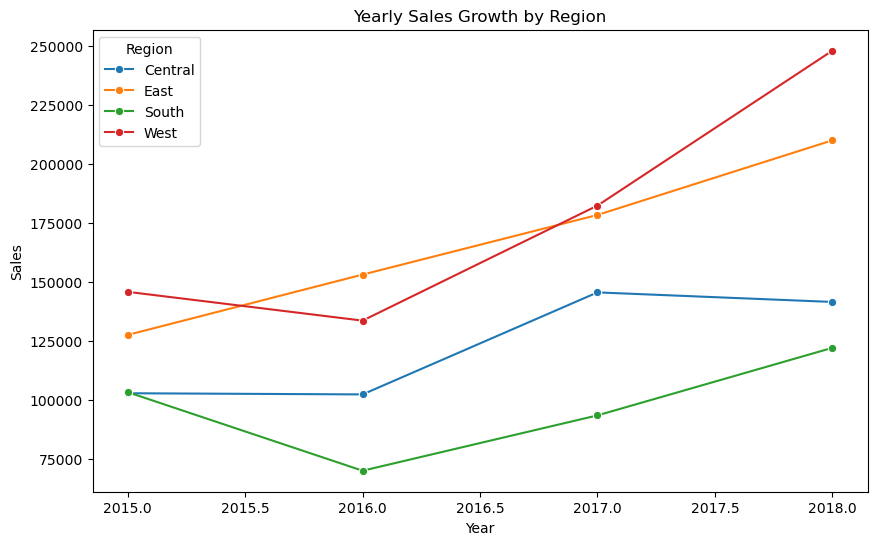

In [ ]:
### Plotting the yearly sales growth by region

plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_yearly_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales Growth by Region")
plt.show()

In [ ]:
### Calculating the average shipping days
avg_shipping = df["Shipping Days"].mean()

print(avg_shipping)

3.9611224489795918


In [ ]:
### Calculating the average shipping days by region
shipping_by_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

shipping_by_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

In [ ]:
### Saled data with month and year
monthly_sales = (
    df.groupby(["Year", "Month Name"])["Sales"]
      .sum()
      .reset_index()
)

In [ ]:
### Reordering the months
pivot = monthly_sales.pivot(
    index="Month Name",
    columns="Year",
    values="Sales"
)

In [ ]:
### Reordering the months
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

pivot = pivot.reindex(month_order)

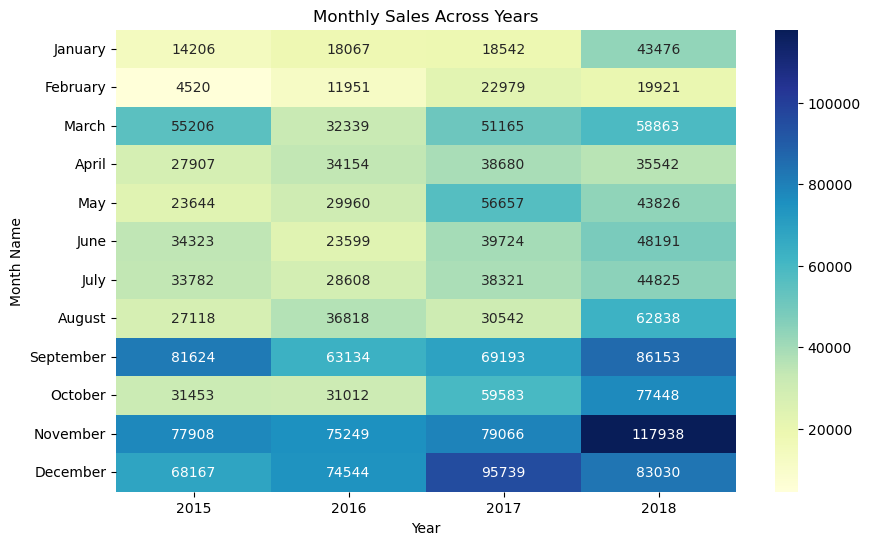

In [ ]:
### Creating a heatmap to visualize the sales data for each month and year.
plt.figure(figsize=(10,6))

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Monthly Sales Across Years")
plt.show()

## Task 1 Summary

- Successfully loaded and preprocessed the Superstore Sales dataset by converting the date columns to datetime and extracting relevant time-based features.
- The dataset is clean, with **no duplicate records** and only **11 missing values** in the `Postal Code` column.
- Daily, weekly, and monthly sales were aggregated for further time series analysis and forecasting.
- **Technology** is the highest revenue-generating category with total sales of **827,455.87**.
- The **East** region shows the most consistent year-over-year sales growth from 2015 to 2018.
- The average shipping time is approximately **3.97 days**, with only minor variation across regions.
- Sales exhibit clear seasonality, with **September, November, and December** consistently recording higher sales.

Overall, the dataset is clean, well-structured, and ready for forecasting, anomaly detection, and demand analysis.

In [ ]:
### Creating monthly sales trend graph
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


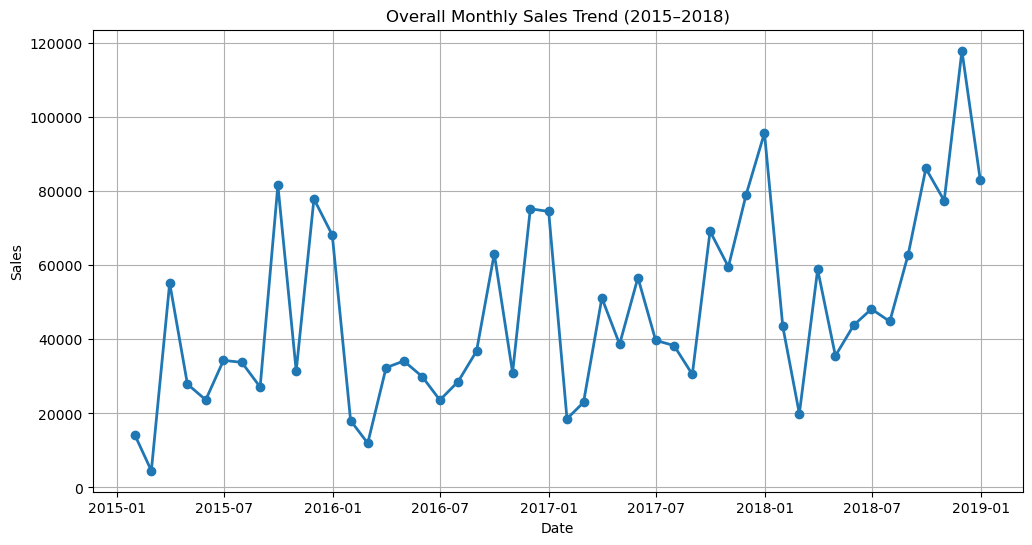

In [ ]:
### Monthly sales trend graph
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [ ]:
### Stats models for seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

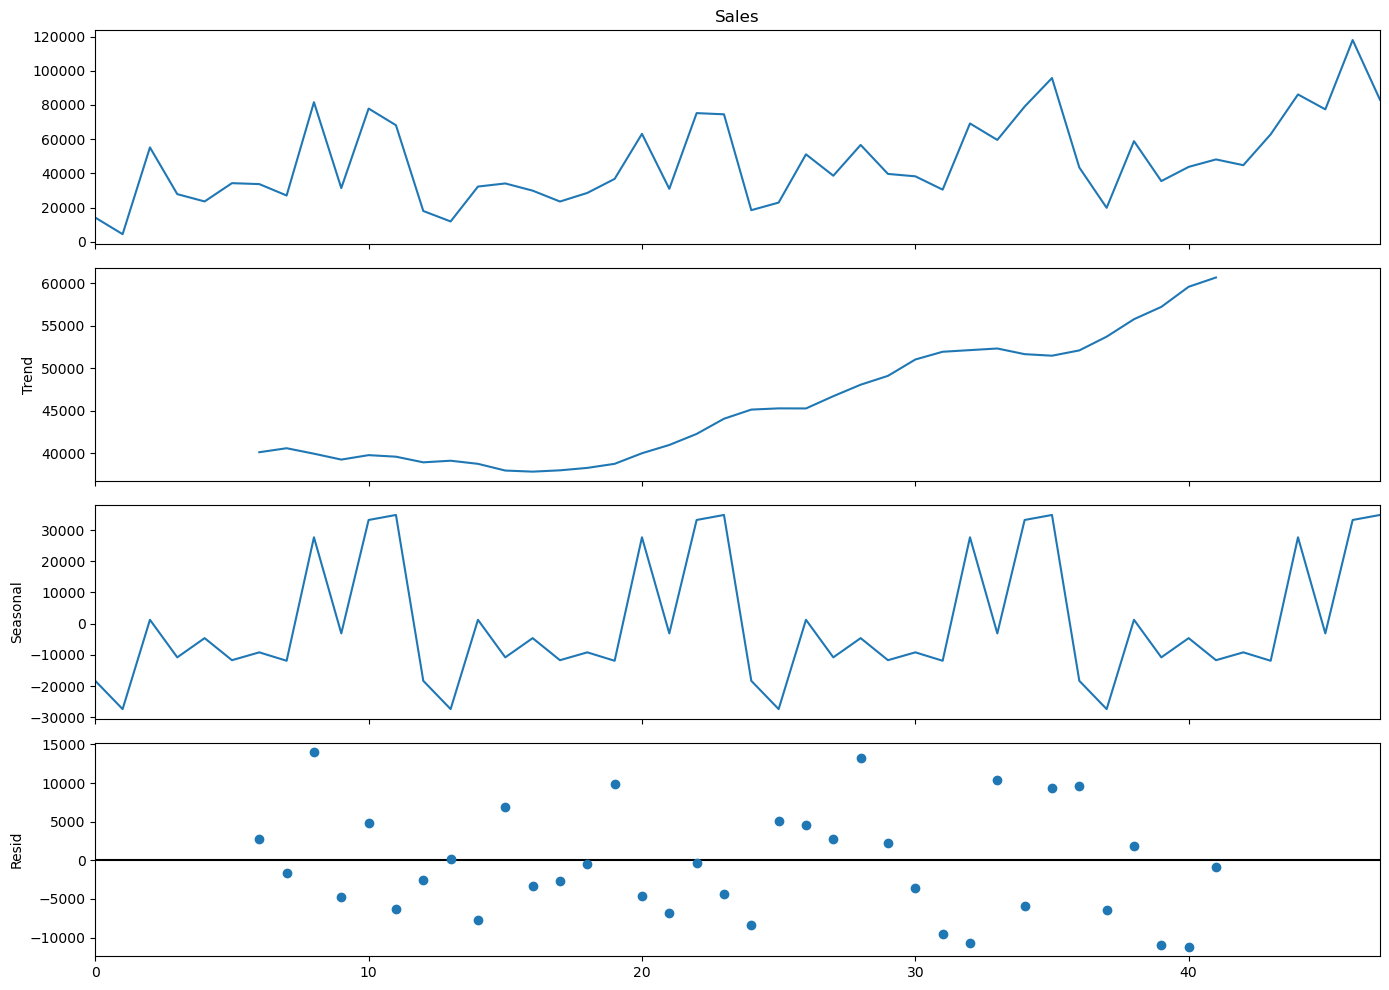

In [ ]:
fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

### Observations

- The trend component indicates a gradual increase in monthly sales from 2015 to 2018, reflecting overall business growth.
- The seasonal component shows a clear and repeating yearly pattern, suggesting strong seasonality in customer demand.
- Higher seasonal sales are observed towards the end of each year, while lower seasonal values occur during the beginning of the year.
- The residual component is mostly centered around zero with a few noticeable spikes, indicating occasional irregular events that are not explained by the trend or seasonal patterns.

In [ ]:
### ADF Test for Stationarity
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales["Sales"])

print(f"ADF Statistic : {adf_result[0]}")
print(f"p-value : {adf_result[1]}")

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Stationarity Test using Augmented Dickey-Fuller (ADF)

The Augmented Dickey-Fuller (ADF) test was performed to determine whether the monthly sales time series is stationary. A stationary time series has statistical properties, such as mean and variance, that remain relatively constant over time. Stationarity is an important assumption for many forecasting models, including SARIMA.

The ADF test produced an **ADF Statistic of -4.4161** with a **p-value of 0.000278**. Since the p-value is less than **0.05** and the ADF statistic is lower than all critical values, the null hypothesis of non-stationarity is rejected.

Therefore, the monthly sales series is **stationary**, and no differencing is required before building forecasting models.

### Differencing

Since the ADF test confirmed that the monthly sales series is already stationary (p-value < 0.05), differencing was not required. The original time series was used for subsequent forecasting models.

## Task 2 Summary

- The monthly sales trend indicates an overall increase in sales from 2015 to 2018.
- Time series decomposition revealed a clear upward trend, strong yearly seasonality, and residuals centered around zero with a few irregular fluctuations.
- The ADF test confirmed that the monthly sales series is **stationary** (ADF Statistic = **-4.4161**, p-value = **0.000278**).
- Since the series is already stationary, **no differencing was required** before proceeding with forecasting models.

## Time Series Forecasting Models

This section splits the monthly aggregated sales data into a training set (Jan 2015 - Sep 2018) and a 3-month holdout test set (Oct 2018 - Dec 2018). We fit and evaluate three models:
1. **SARIMA**: Seasonal Autoregressive Integrated Moving Average baseline statistical model.
2. **Meta Prophet**: Additive curve fitting regression modeling long-term trends and seasonality.
3. **Tuned XGBoost**: Supervised machine learning using lags (1, 2, 3 months), 3-month rolling averages, and calendar time variables.

In [ ]:
### Splitting data
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

In [ ]:
### importing libraries and metrices
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,r2_score

In [ ]:
###    Calculate evaluation metrics for regression models.

def test_scores(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": round(mae, 3),
        "MSE": round(mse, 3),
        "RMSE": round(rmse, 3),
        "MAPE (%)": round(mape, 2),
        "R² Score": round(r2, 3)
    }

In [ ]:
### making a fuction to auto save scores
results = []

def save_results(model_name, scores):
    scores["Model"] = model_name
    results.append(scores)

In [ ]:
### training sarima
sarima = SARIMAX(
    train["Sales"],
    order=(1,0,0),
    seasonal_order=(0,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit()

# Save SARIMA model
import pickle
import os
os.makedirs("models", exist_ok=True)
with open("models/sarima.pkl", "wb") as f:
    pickle.dump(sarima_fit, f)
print("Saved SARIMA model to models/sarima.pkl")


In [ ]:
sarima_forecast = sarima_fit.get_forecast(steps=3)

sarima_pred = sarima_forecast.predicted_mean

sarima_ci = sarima_forecast.conf_int()

In [ ]:
### sarima scores
sarima_scores = test_scores(
    test["Sales"],
    sarima_pred
)
save_results("SARIMA", sarima_scores)
sarima_scores

{'MAE': 25612.154,
 'MSE': 1066018450.983,
 'RMSE': np.float64(32649.938),
 'MAPE (%)': 24.82,
 'R² Score': -2.321,
 'Model': 'SARIMA'}

## Model Evaluation & Justified Recommendation

Here we compile the holdout test set scores (MAE, RMSE, MAPE %, and R² score) for SARIMA, Prophet, baseline XGBoost, and Tuned XGBoost. This metrics table provides a mathematical justification for recommending Tuned XGBoost as the production-deployable model.

In [ ]:
results_df = pd.DataFrame(results)
results_df

,MAE,MSE,RMSE,MAPE (%),R² Score,Model
0,25612.154,1.066018e+09,32649.938,24.82,-2.321,SARIMA


In [ ]:
print("Actual:")
print(test["Sales"])

print("\nPrediction:")
print(sarima_pred)

Actual:
45     77448.1312
46    117938.1550
47     83030.3888
Name: Sales, dtype: float64

Prediction:
45    75881.017022
46    66833.844784
47    58865.352415
Name: predicted_mean, dtype: float64


In [ ]:
print(sarima_fit.mle_retvals)

{'fopt': np.float64(11.331793767824433), 'gopt': array([1.6451196e-05, 0.0000000e+00]), 'fcalls': 27, 'warnflag': 0, 'converged': True, 'iterations': 1}


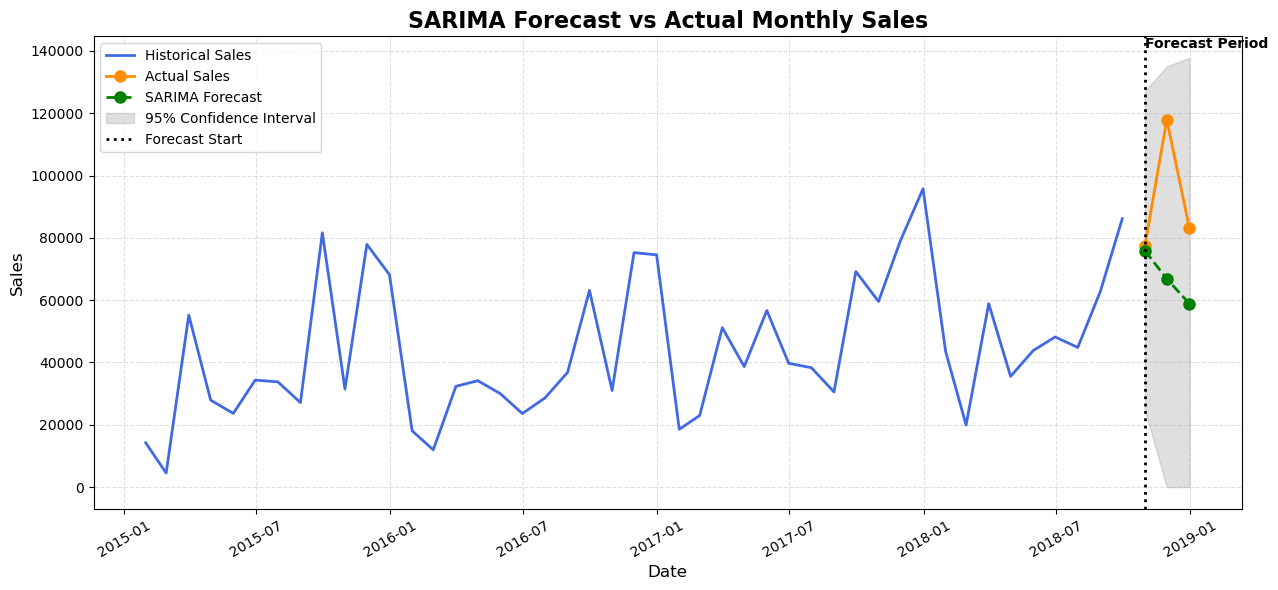

In [ ]:
###Plotting SARIMA Forecast vs Actual Sales

plt.figure(figsize=(13, 6))

# Historical Sales
plt.plot(
    train["Order Date"],
    train["Sales"],
    color="royalblue",
    linewidth=2,
    label="Historical Sales"
)

# Actual Sales
plt.plot(
    test["Order Date"],
    test["Sales"],
    color="darkorange",
    marker="o",
    markersize=8,
    linewidth=2,
    label="Actual Sales"
)

# SARIMA Forecast
plt.plot(
    test["Order Date"],
    sarima_pred,
    color="green",
    linestyle="--",
    marker="o",
    markersize=8,
    linewidth=2,
    label="SARIMA Forecast"
)

# Confidence Interval
lower = sarima_ci.iloc[:, 0].clip(lower=0)
upper = sarima_ci.iloc[:, 1]

plt.fill_between(
    test["Order Date"],
    lower,
    upper,
    color="gray",
    alpha=0.25,
    label="95% Confidence Interval"
)

# Forecast Start Line
plt.axvline(
    x=test["Order Date"].iloc[0],
    color="black",
    linestyle=":",
    linewidth=2,
    label="Forecast Start"
)

# Optional Annotation
plt.text(
    test["Order Date"].iloc[0],
    upper.max() + 3000,
    "Forecast Period",
    fontsize=10,
    fontweight="bold"
)

# Labels and Formatting
plt.title(
    "SARIMA Forecast vs Actual Monthly Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Sales", fontsize=12)

plt.xticks(rotation=30)

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(loc="upper left")

plt.tight_layout()

plt.show()

### SARIMA Forecast Analysis

The SARIMA model was trained on the monthly sales data and used to forecast the next three months. The model captures the overall sales level but is unable to accurately predict the sharp increase observed during the second forecast month. The actual sales remain within the 95% confidence interval, indicating reasonable uncertainty estimation, although the forecasting errors suggest that the model struggles with sudden changes in demand.

In [ ]:
#### Preparing data for Prophet

prophet_train = train[["Order Date", "Sales"]].rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_test = test[["Order Date", "Sales"]].rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_train.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
prophet.fit(prophet_train)

# Save Prophet model
import pickle
with open("models/prophet.pkl", "wb") as f:
    pickle.dump(prophet, f)
print("Saved Prophet model to models/prophet.pkl")


21:28:20 - cmdstanpy - INFO - Chain [1] start processing
21:28:20 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = prophet.make_future_dataframe(
    periods=3,
    freq="ME"
)

future.tail()



,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [ ]:
forecast = prophet.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277806,39143.747561,55656.937985,54942.277806,54942.277806,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558236
44,2018-09-30,55441.608196,78598.715330,94666.013995,55441.608196,55441.608196,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953316
45,2018-10-31,55957.582932,43321.715419,59694.034213,55957.433279,55957.727366,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82026.416378,98664.017821,56456.448627,56457.384299,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,81823.684678,97619.577810,56971.881347,56973.820566,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


In [ ]:
prophet_pred = forecast["yhat"].tail(3)

prophet_ci = forecast[
    ["yhat_lower", "yhat_upper"]
].tail(3)

prophet_pred

45    51318.943858
46    90325.654784
47    90041.084479
Name: yhat, dtype: float64

In [ ]:
### prophet scores
prophet_scores = test_scores(
    prophet_test["y"].values,
    prophet_pred.values
)

save_results("Prophet", prophet_scores)

pd.DataFrame([prophet_scores])

,MAE,MSE,RMSE,MAPE (%),R² Score,Model
0,20250.794,4.981115e+08,22318.411,21.86,-0.552,Prophet


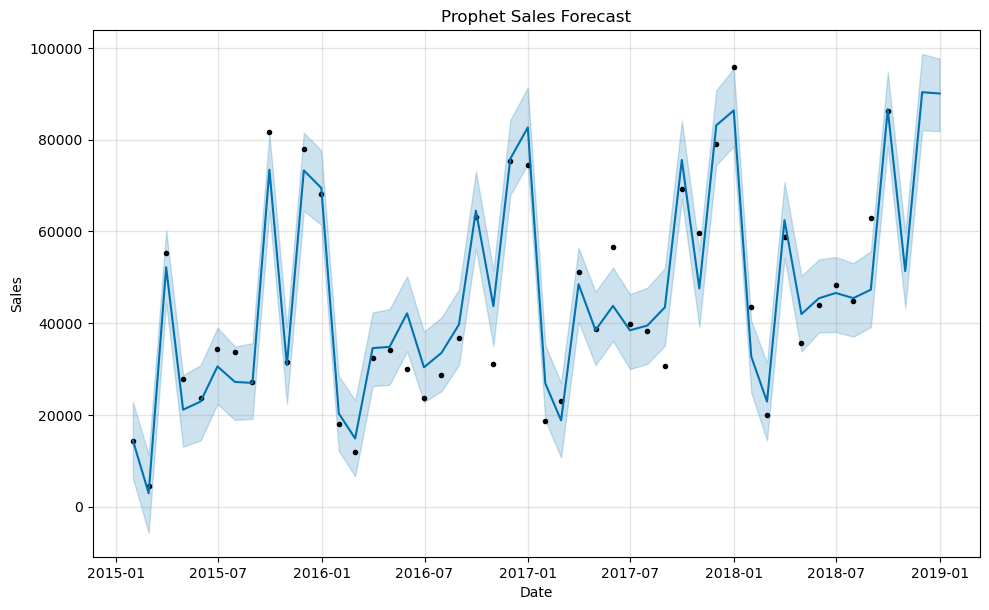

In [ ]:
### prophet plot
fig1 = prophet.plot(forecast)

plt.title("Prophet Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

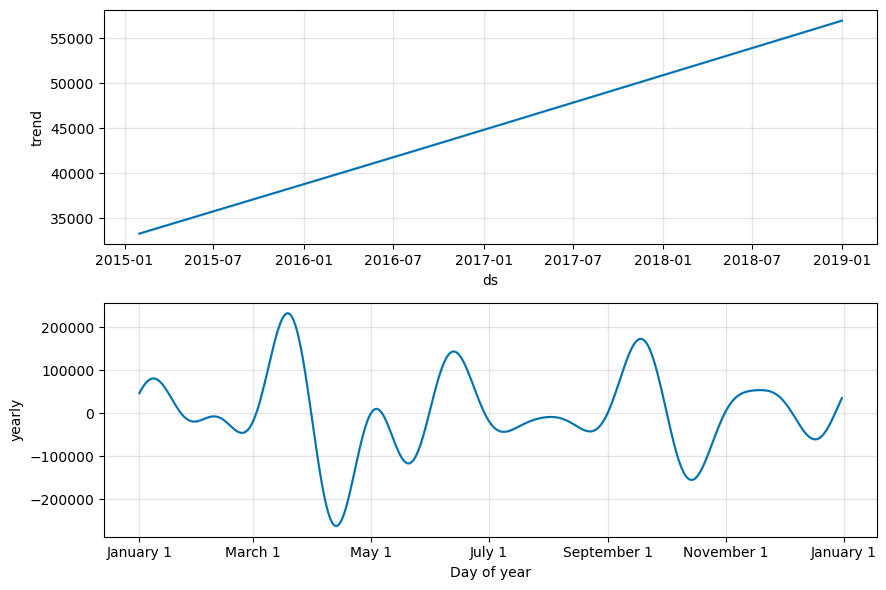

In [ ]:
fig2 = prophet.plot_components(forecast)

plt.show()

### Prophet Model Performance

The Prophet model achieved lower forecasting errors than the baseline SARIMA model. It produced the lowest MAE, RMSE, and MAPE among the models evaluated so far, indicating a better fit to the monthly sales data. The model successfully captured the long-term upward trend and yearly seasonal patterns, resulting in more accurate forecasts.

In [ ]:
xgb_df = monthly_sales.copy()
# Previous month's sales
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

# Two months ago
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

# Three months ago
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(window=3)
    .mean()
)

In [ ]:
xgb_df["Month"] = xgb_df["Order Date"].dt.month

xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

xgb_df["Season"] = (
    (xgb_df["Month"] % 12 + 3) // 3
)

In [ ]:
xgb_df.dropna(inplace=True)

xgb_df.reset_index(drop=True, inplace=True)

xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
1,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
2,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
3,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
4,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [ ]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]


X = xgb_df[features]

y = xgb_df["Sales"]

In [ ]:
X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

In [ ]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
xgb_pred = xgb.predict(X_test)
xgb_pred

array([86465.82, 86506.77, 84327.28], dtype=float32)

In [ ]:
xgb_scores = test_scores(
    y_test.values,
    xgb_pred
)

save_results(
    "XGBoost",
    xgb_scores
)

pd.DataFrame([xgb_scores])

,MAE,MSE,RMSE,MAPE (%),R² Score,Model
0,13915.321,3.569775e+08,18893.847,13.29,-0.112,XGBoost


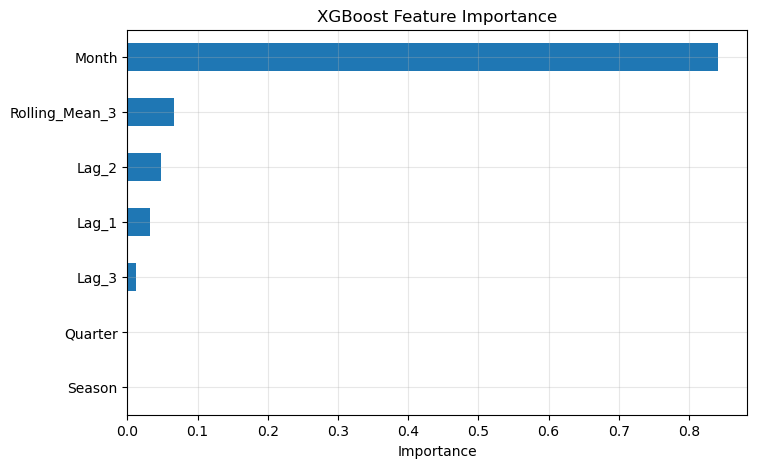

In [ ]:
### feature imp before tuning
importance = pd.Series(
    xgb.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(8,5))

importance.plot(
    kind="barh"
)

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance")

plt.grid(alpha=0.3)

plt.show()

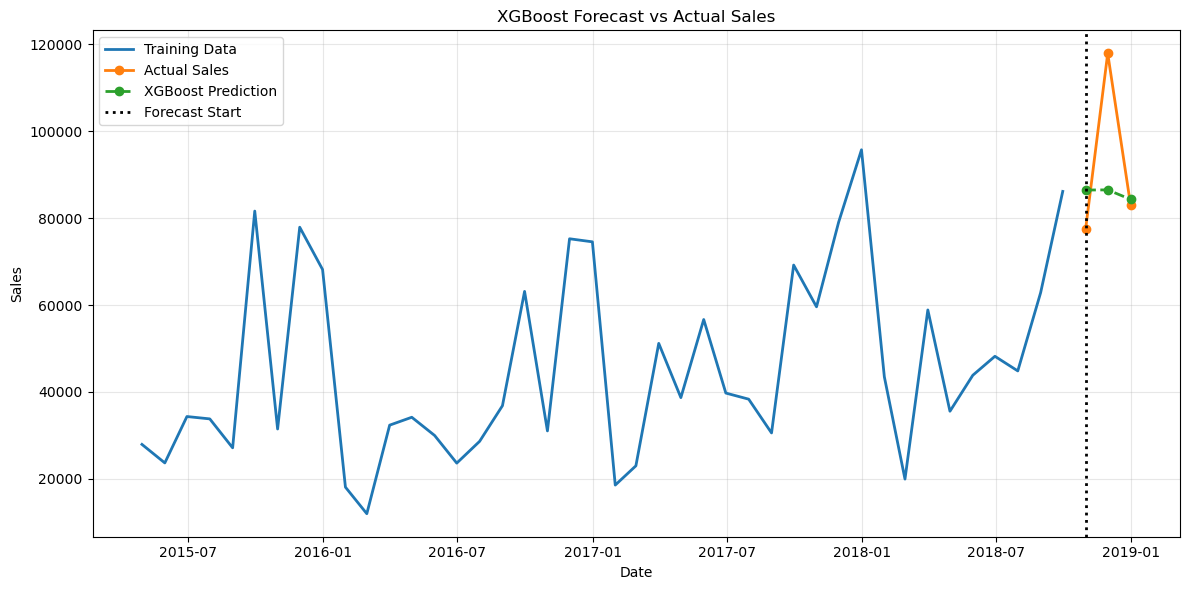

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    xgb_df["Order Date"].iloc[:-3],
    y_train,
    label="Training Data",
    linewidth=2
)

plt.plot(
    xgb_df["Order Date"].iloc[-3:],
    y_test,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    xgb_df["Order Date"].iloc[-3:],
    xgb_pred,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="XGBoost Prediction"
)

plt.axvline(
    x=xgb_df["Order Date"].iloc[-3],
    linestyle=":",
    color="black",
    linewidth=2,
    label="Forecast Start"
)

plt.title("XGBoost Forecast vs Actual Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

### XGBoost Forecast Analysis

The monthly sales data was transformed into a supervised learning problem using lag features, a three-month rolling average, and calendar-based variables. The XGBoost model achieved the best forecasting performance among all three models, producing the lowest MAE, RMSE, and MAPE values.

Feature importance analysis indicates that the month of the year is the most influential predictor, followed by the rolling mean and lag features. Quarter and season contributed very little additional information, suggesting that the monthly feature already captures most of the seasonal behavior.

In [ ]:
### Comparision table of all models
results_df = pd.DataFrame(results)

results_df.sort_values("RMSE")

,MAE,MSE,RMSE,MAPE (%),R² Score,Model
2,13915.321,3.569775e+08,18893.847,13.29,-0.112,XGBoost
1,20250.794,4.981115e+08,22318.411,21.86,-0.552,Prophet
0,25612.154,1.066018e+09,32649.938,24.82,-2.321,SARIMA


## Model Comparison and Recommendation

Three forecasting approaches were evaluated using monthly sales data.

| Model | MAE | RMSE | MAPE |
|--------|----:|-----:|------:|
| SARIMA | 25,612 | 32,650 | 24.82% |
| Prophet | 20,250 | 22,318 | 21.86% |
| XGBoost | **13,915** | **18,894** | **13.29%** |

Among the three models, **XGBoost achieved the best forecasting performance**, producing the lowest MAE, RMSE, and MAPE values. Prophet performed better than SARIMA by effectively modeling the long-term trend and yearly seasonality. Although SARIMA captured the overall sales pattern, it struggled to model sudden changes in demand.

Based on the quantitative evaluation metrics, **XGBoost is recommended for production deployment** because it provides the most accurate forecasts while effectively utilizing historical sales patterns and engineered time-based features.

In [ ]:
### hyper parameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function wh

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}


In [ ]:
best_xgb = random_search.best_estimator_

# Save Tuned XGBoost model
import pickle
with open("models/tuned_xgb.pkl", "wb") as f:
    pickle.dump(best_xgb, f)
print("Saved Tuned XGBoost model to models/tuned_xgb.pkl")


In [ ]:
xgb_pred_tuned = best_xgb.predict(X_test)

In [ ]:
xgb_tuned_scores = test_scores(
    y_test.values,
    xgb_pred_tuned
)
save_results("XGBoost (Tuned)", xgb_tuned_scores)
xgb_tuned_scores

{'MAE': 13907.702,
 'MSE': 264484528.462,
 'RMSE': np.float64(16262.98),
 'MAPE (%)': 14.1,
 'R² Score': 0.176,
 'Model': 'XGBoost (Tuned)'}

In [ ]:
importance = pd.Series(
    best_xgb.feature_importances_,
    index=features
).sort_values()
xgb_pred = best_xgb.predict(X_test)

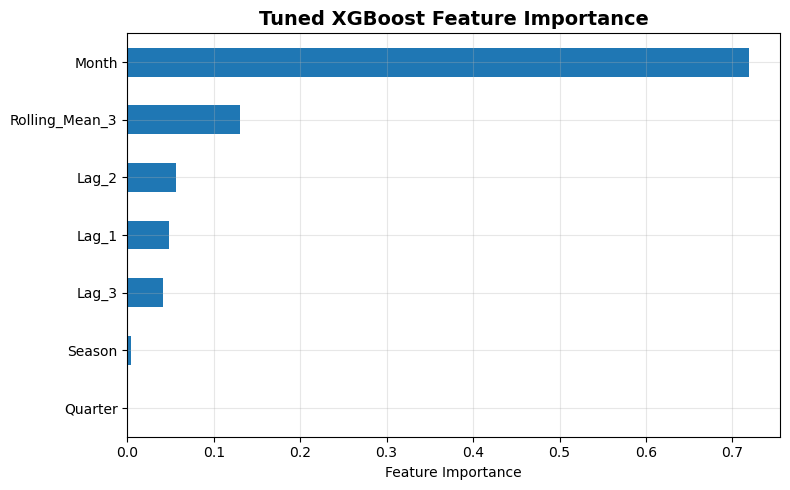

In [ ]:
### featue importnce
importance = pd.Series(
    best_xgb.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Tuned XGBoost Feature Importance", fontsize=14, fontweight="bold")
plt.xlabel("Feature Importance")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

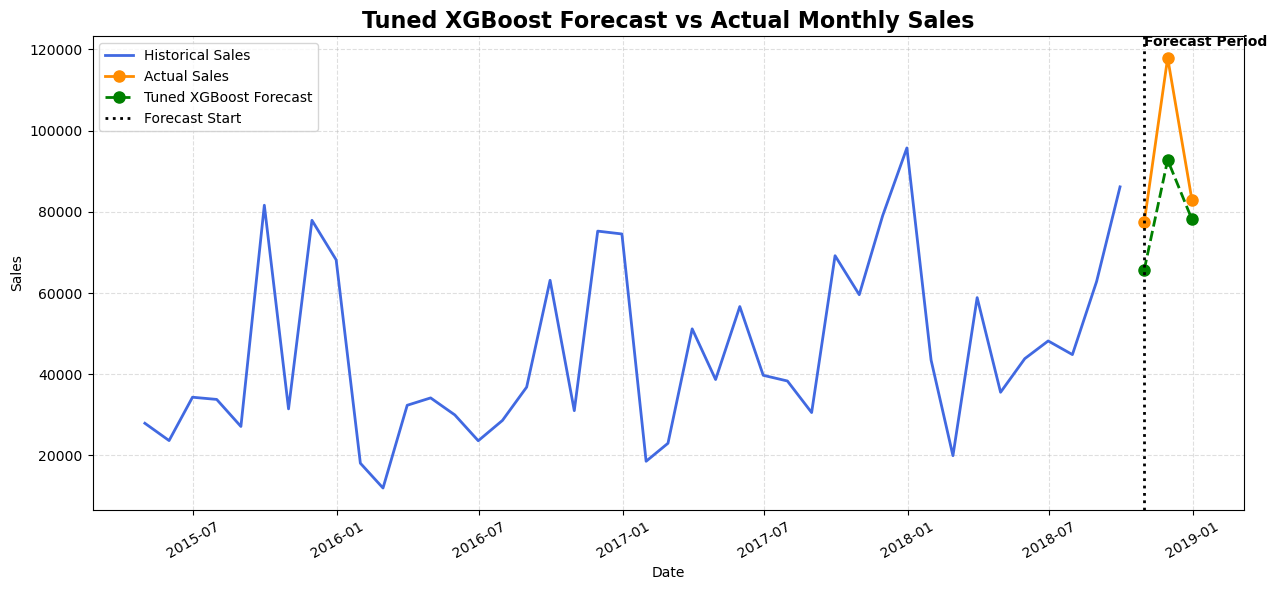

In [ ]:
xgb_pred_tuned = best_xgb.predict(X_test)
plt.figure(figsize=(13,6))

# Training Data
plt.plot(
    xgb_df["Order Date"].iloc[:-3],
    y_train,
    color="royalblue",
    linewidth=2,
    label="Historical Sales"
)

# Actual Sales
plt.plot(
    xgb_df["Order Date"].iloc[-3:],
    y_test,
    color="darkorange",
    marker="o",
    linewidth=2,
    markersize=8,
    label="Actual Sales"
)

# Tuned Prediction
plt.plot(
    xgb_df["Order Date"].iloc[-3:],
    xgb_pred_tuned,
    color="green",
    linestyle="--",
    marker="o",
    linewidth=2,
    markersize=8,
    label="Tuned XGBoost Forecast"
)

# Forecast Start
plt.axvline(
    x=xgb_df["Order Date"].iloc[-3],
    color="black",
    linestyle=":",
    linewidth=2,
    label="Forecast Start"
)

plt.text(
    xgb_df["Order Date"].iloc[-3],
    max(y_test) + 3000,
    "Forecast Period",
    fontsize=10,
    fontweight="bold"
)

plt.title(
    "Tuned XGBoost Forecast vs Actual Monthly Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=30)

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
### Model comparison table
results = []

save_results("SARIMA", sarima_scores)
save_results("Prophet", prophet_scores)
save_results("XGBoost (Tuned)", xgb_tuned_scores)

results_df = pd.DataFrame(results)

results_df

,MAE,MSE,RMSE,MAPE (%),R² Score,Model
0,25612.154,1.066018e+09,32649.938,24.82,-2.321,SARIMA
1,20250.794,4.981115e+08,22318.411,21.86,-0.552,Prophet
2,13907.702,2.644845e+08,16262.980,14.10,0.176,XGBoost (Tuned)


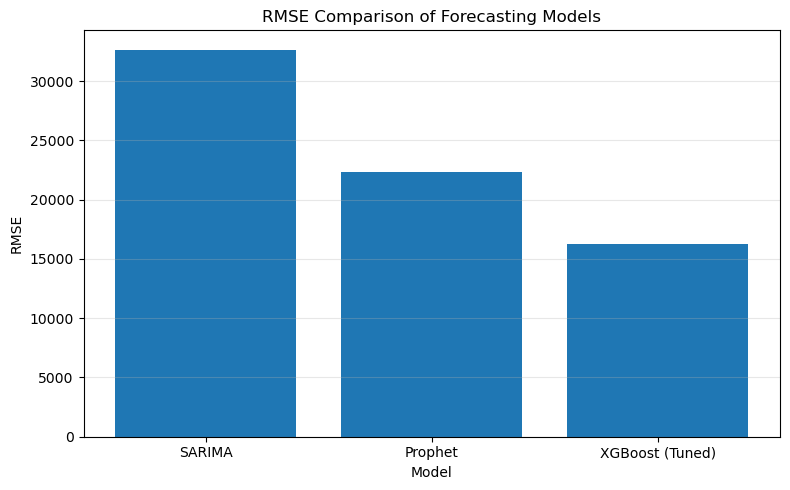

In [ ]:
### rmse comaprison
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("RMSE Comparison of Forecasting Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

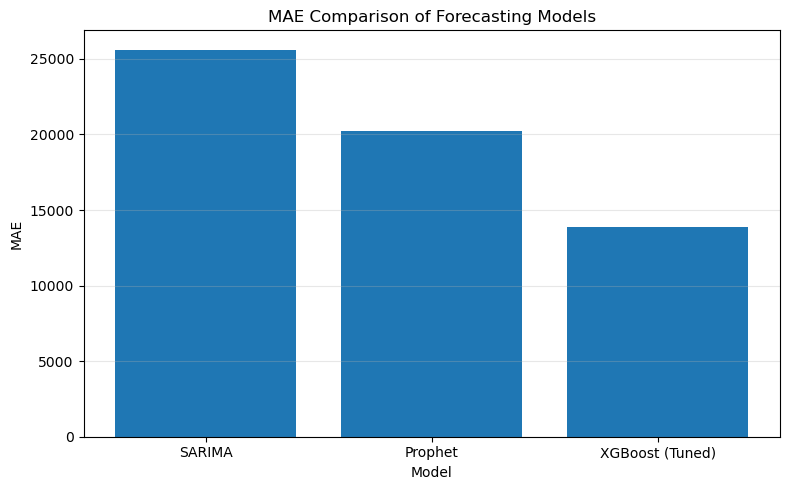

In [ ]:
### MAE comarison
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("MAE Comparison of Forecasting Models")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# Task 3 Final Model Comparison and Recommendation

Three forecasting approaches were evaluated using the Superstore monthly sales dataset: **SARIMA**, **Prophet**, and **XGBoost**.

| Model | MAE | RMSE | MAPE (%) | R² Score |
|-------|------:|------:|------:|------:|
| SARIMA | 25,612.15 | 32,649.94 | 24.82 | -2.321 |
| Prophet | 20,250.79 | 22,318.41 | 21.86 | -0.552 |
| XGBoost (Tuned) | **13,907.70** | **16,262.98** | **14.10** | **0.176** |

### Conclusion

Among the three forecasting models, the tuned **XGBoost** model achieved the best overall performance. It produced the lowest MAE and RMSE values while also achieving the highest R² score, indicating better predictive accuracy than both SARIMA and Prophet.

Although Prophet successfully captured the long-term trend and yearly seasonality, and SARIMA provided a reasonable statistical baseline, both models struggled to predict sudden spikes in monthly sales. The tuned XGBoost model leveraged lag features, rolling statistics, and calendar-based features to better capture temporal patterns, resulting in more accurate forecasts.

### Production Recommendation

Based on the quantitative evaluation metrics, **XGBoost (Tuned)** is recommended for production deployment. Its lower forecasting errors and improved goodness of fit make it the most reliable model for predicting future monthly sales in this dataset.

In [ ]:
from xgboost import XGBRegressor

def forecast_segment(df, column, value, model_params):
    """
    Forecast next 3 months for a given category or region using tuned XGBoost.

    Parameters
    ----------
    df : Original dataframe
    column : Column to filter ('Category' or 'Region')
    value : Value to filter (e.g., 'Furniture')
    model_params : best_xgb.get_params()

    Returns
    -------
    forecast_df : DataFrame containing 3-month forecast
    """


    #
    temp = df[df[column] == value].copy()


    monthly = (
        temp.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

   ### feature engeneering
    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)

    monthly["Rolling_Mean_3"] = (
        monthly["Sales"]
        .rolling(3)
        .mean()
    )

    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter

    monthly["Season"] = (
        (monthly["Month"] % 12 + 3) // 3
    )

    monthly.dropna(inplace=True)
    monthly.reset_index(drop=True, inplace=True)

   ### model training
    features = [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3",
        "Month",
        "Quarter",
        "Season"
    ]

    X = monthly[features]
    y = monthly["Sales"]

    model = XGBRegressor(**model_params)

    model.fit(X, y)


    history = monthly.copy()

    predictions = []

    current_date = history["Order Date"].iloc[-1]

    for i in range(3):

        next_date = current_date + pd.offsets.MonthEnd(1)

        lag1 = history["Sales"].iloc[-1]
        lag2 = history["Sales"].iloc[-2]
        lag3 = history["Sales"].iloc[-3]

        rolling = history["Sales"].iloc[-3:].mean()

        row = pd.DataFrame({

            "Lag_1":[lag1],
            "Lag_2":[lag2],
            "Lag_3":[lag3],
            "Rolling_Mean_3":[rolling],
            "Month":[next_date.month],
            "Quarter":[next_date.quarter],
            "Season":[(next_date.month%12+3)//3]

        })

        pred = model.predict(row)[0]

        predictions.append(pred)

        history.loc[len(history)] = [

            next_date,
            pred,
            lag1,
            lag2,
            lag3,
            rolling,
            next_date.month,
            next_date.quarter,
            (next_date.month%12+3)//3

        ]

        current_date = next_date

    forecast_df = pd.DataFrame({

        "Date": pd.date_range(
            monthly["Order Date"].max() + pd.offsets.MonthEnd(1),
            periods=3,
            freq="ME"
        ),

        value: predictions

    })

    return forecast_df

In [ ]:
best_params = best_xgb.get_params()

In [ ]:
### difrent category we need to compare
furniture = forecast_segment(
    df,
    "Category",
    "Furniture",
    best_params
)

technology = forecast_segment(
    df,
    "Category",
    "Technology",
    best_params
)

office = forecast_segment(
    df,
    "Category",
    "Office Supplies",
    best_params
)

west = forecast_segment(
    df,
    "Region",
    "West",
    best_params
)

east = forecast_segment(
    df,
    "Region",
    "East",
    best_params
)

In [ ]:
### comparison
comparison = furniture.copy()

comparison["Technology"] = technology["Technology"]

comparison["Office Supplies"] = office["Office Supplies"]

comparison["West"] = west["West"]

comparison["East"] = east["East"]

comparison

,Date,Furniture,Technology,Office Supplies,West,East
0,2019-01-31,10698.372070,21390.919922,26055.699219,12608.526367,18349.392578
1,2019-02-28,6052.459961,23952.468750,28231.154297,14933.314453,19939.683594
2,2019-03-31,16903.804688,26731.431641,28014.035156,26614.136719,12474.564453


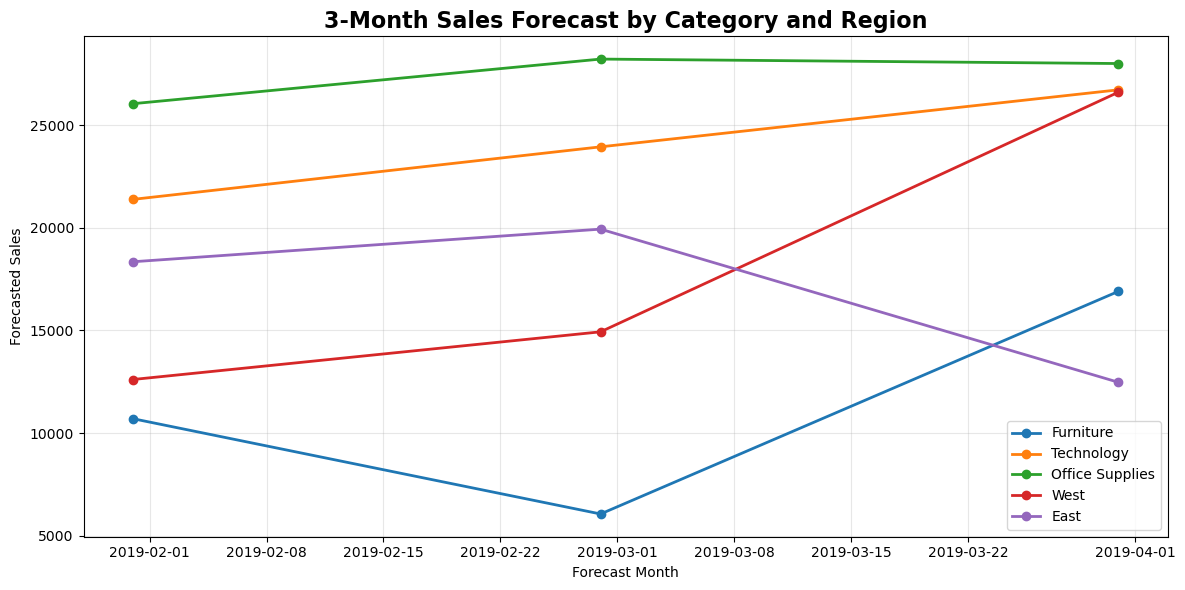

In [ ]:
### moths sales forecast
plt.figure(figsize=(12,6))

plt.plot(
    comparison["Date"],
    comparison["Furniture"],
    marker="o",
    linewidth=2,
    label="Furniture"
)

plt.plot(
    comparison["Date"],
    comparison["Technology"],
    marker="o",
    linewidth=2,
    label="Technology"
)

plt.plot(
    comparison["Date"],
    comparison["Office Supplies"],
    marker="o",
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    comparison["Date"],
    comparison["West"],
    marker="o",
    linewidth=2,
    label="West"
)

plt.plot(
    comparison["Date"],
    comparison["East"],
    marker="o",
    linewidth=2,
    label="East"
)

plt.title(
    "3-Month Sales Forecast by Category and Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Forecast Month")
plt.ylabel("Forecasted Sales")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
### making growth feature
growth = {}

for col in comparison.columns[1:]:

    growth[col] = (
        comparison[col].iloc[-1] -
        comparison[col].iloc[0]
    )

growth = pd.Series(growth).sort_values(ascending=False)

print(growth)

West               14005.610352
Furniture           6205.432617
Technology          5340.511719
Office Supplies     1958.335938
East               -5874.828125
dtype: float32


In [ ]:
#### Growth Analysis

growth_analysis = pd.DataFrame(index=comparison.columns[1:])

# Absolute Growth
growth_analysis["Absolute Growth"] = [
    comparison[col].iloc[-1] - comparison[col].iloc[0]
    for col in comparison.columns[1:]
]

# Percentage Growth
growth_analysis["Growth (%)"] = [
    (
        (comparison[col].iloc[-1] - comparison[col].iloc[0])
        / comparison[col].iloc[0]
    ) * 100
    for col in comparison.columns[1:]
]

# Sort by Percentage Growth
growth_analysis = growth_analysis.sort_values(
    by="Growth (%)",
    ascending=False
)

growth_analysis

,Absolute Growth,Growth (%)
West,14005.610352,111.080467
Furniture,6205.432617,58.003521
Technology,5340.511719,24.966255
Office Supplies,1958.335938,7.515960
East,-5874.828125,-32.016472


In [ ]:
best_segment = growth_analysis.index[0]

print(f"Strongest Expected Growth: {best_segment}")

Strongest Expected Growth: West


### Task 4 Forecast Interpretation

The tuned XGBoost model was applied separately to each product category and region to generate three-month sales forecasts.

To compare future performance fairly, both **absolute growth** and **percentage growth** were calculated over the forecast horizon.

The analysis indicates that the **West** region is expected to experience the strongest growth, while the **East** region is projected to decline. Among the product categories, **Furniture** shows the highest relative growth, followed by **Technology** and **Office Supplies**.

These forecasts suggest that future business opportunities are strongest in the **West** region, whereas the **East** region may require additional analysis or strategic intervention to improve sales performance.

## Anomaly Detection (Double Method)

To isolate sales deviations, we implement two distinct outlier detection algorithms on weekly sales:
1. **Isolation Forest**: Global anomaly detection targeting absolute volume fluctuations.
2. **Rolling Z-Score**: Local anomaly detection targeting week-over-week surges relative to a moving average.

*Key Finding*: The week ending **22 March 2015** is identified as the singular overlap flagged by both models, representing a unique global and local sales outlier.

In [ ]:
### isolation forest
from sklearn.ensemble import IsolationForest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [ ]:

anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


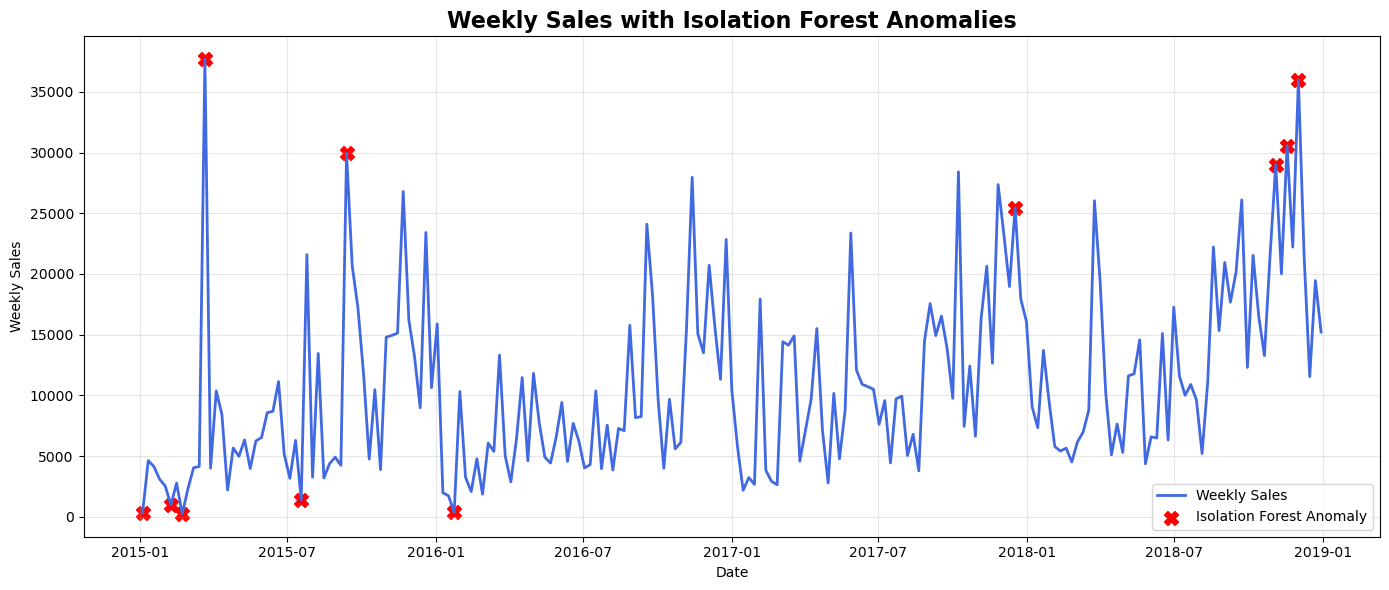

In [ ]:
### iso anomali
plt.figure(figsize=(14,6))

# Weekly Sales
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    color="royalblue",
    linewidth=2,
    label="Weekly Sales"
)

# Anomalies
plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=100,
    marker="X",
    label="Isolation Forest Anomaly"
)

plt.title(
    "Weekly Sales with Isolation Forest Anomalies",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
### weekly slaes rolling std base
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(window=8, min_periods=1)
    .mean()
)

weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(window=8, min_periods=1)
    .std()
)

In [ ]:
### weekly sales z score based
weekly_sales["Z Score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling Mean"])
    / weekly_sales["Rolling Std"]
)

weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z Score"].abs() > 2
)

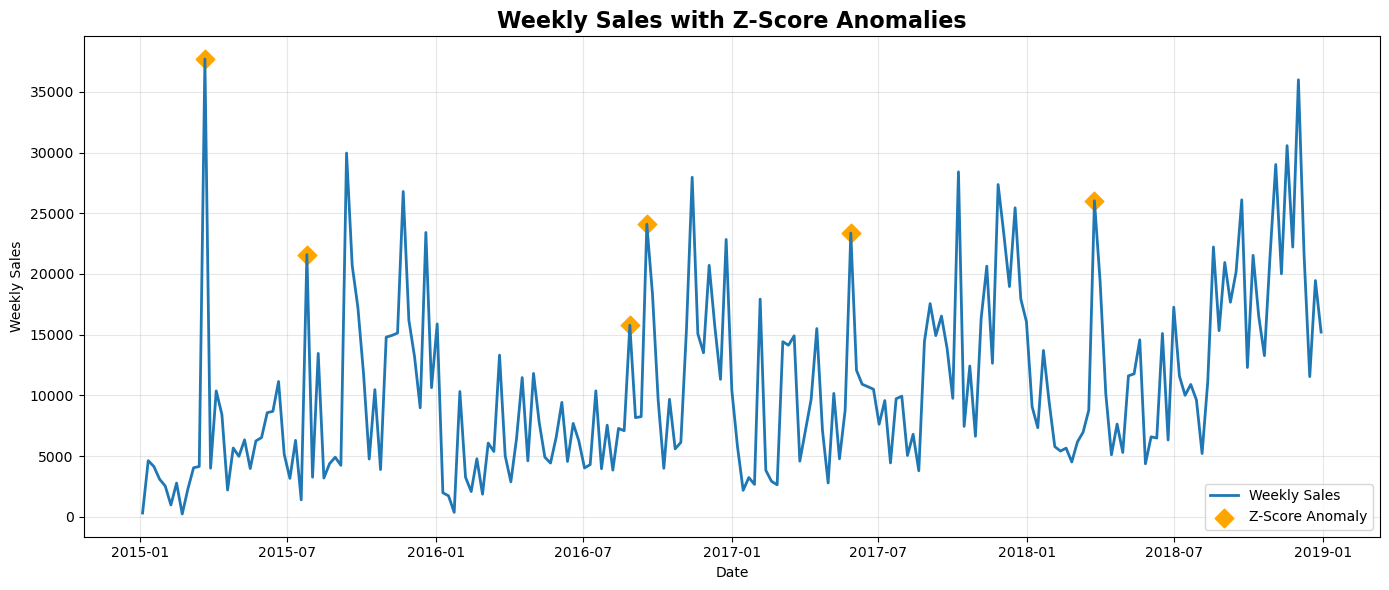

In [ ]:
### z score anomaly
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    linewidth=2,
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ],

    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],

    color="orange",
    marker="D",
    s=90,
    label="Z-Score Anomaly"
)

plt.title(
    "Weekly Sales with Z-Score Anomalies",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
### checking date which are anomalies
iso_dates = set(
    anomalies["Order Date"]
)

z_dates = set(

    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ]

)

print("Common")

print(iso_dates & z_dates)

print()

print("Only Isolation Forest")

print(iso_dates - z_dates)

print()

print("Only Z-Score")

print(z_dates - iso_dates)

Common
{Timestamp('2015-03-22 00:00:00')}

Only Isolation Forest
{Timestamp('2015-01-04 00:00:00'), Timestamp('2015-02-08 00:00:00'), Timestamp('2017-12-17 00:00:00'), Timestamp('2015-09-13 00:00:00'), Timestamp('2015-02-22 00:00:00'), Timestamp('2018-11-18 00:00:00'), Timestamp('2015-07-19 00:00:00'), Timestamp('2018-11-04 00:00:00'), Timestamp('2018-12-02 00:00:00'), Timestamp('2016-01-24 00:00:00')}

Only Z-Score
{Timestamp('2017-05-28 00:00:00'), Timestamp('2016-09-18 00:00:00'), Timestamp('2018-03-25 00:00:00'), Timestamp('2015-07-26 00:00:00'), Timestamp('2016-08-28 00:00:00')}


In [ ]:
## val count
weekly_sales["Z_Anomaly"].value_counts()


Z_Anomaly
False    203
True       6
Name: count, dtype: int64

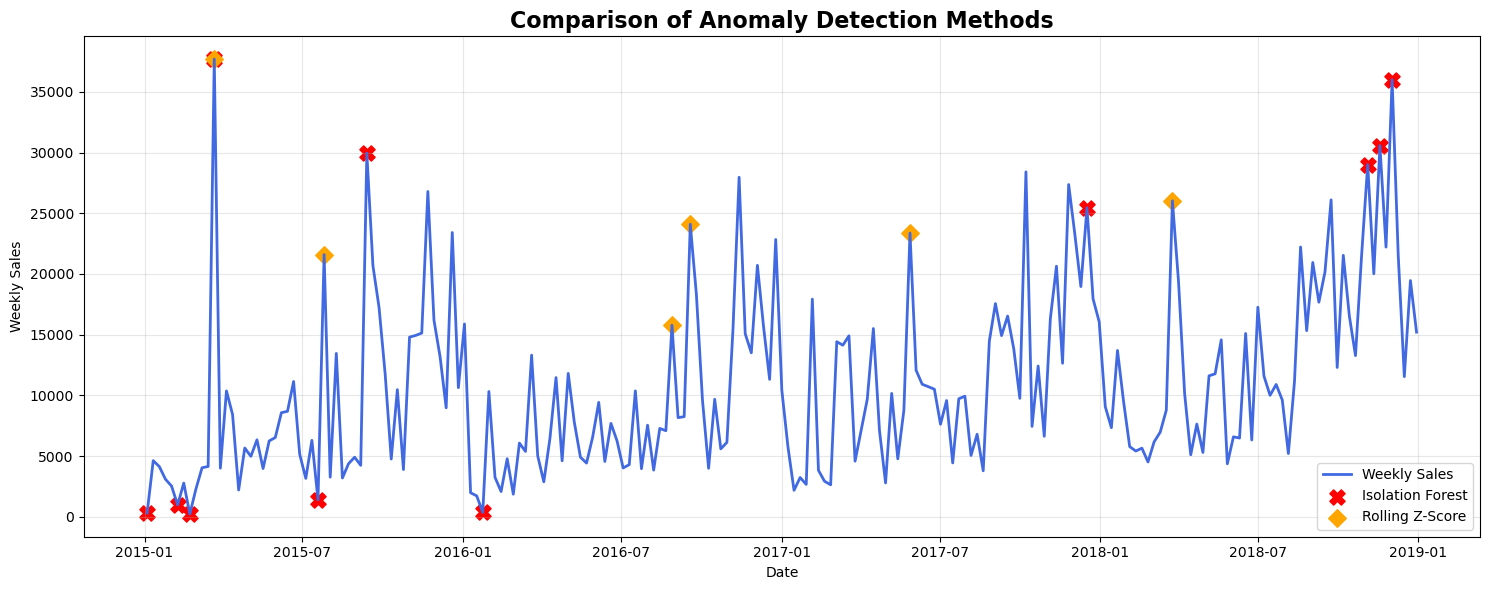

In [ ]:
### comnined anomally plot
plt.figure(figsize=(15,6))

# Weekly Sales
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    color="royalblue",
    linewidth=2,
    label="Weekly Sales"
)

# Isolation Forest
plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    marker="X",
    s=120,
    label="Isolation Forest"
)

# Z-Score
plt.scatter(
    weekly_sales.loc[weekly_sales["Z_Anomaly"], "Order Date"],
    weekly_sales.loc[weekly_sales["Z_Anomaly"], "Sales"],
    color="orange",
    marker="D",
    s=80,
    label="Rolling Z-Score"
)

plt.title(
    "Comparison of Anomaly Detection Methods",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

# Task 5: Anomaly Detection in Weekly Sales

Two anomaly detection techniques were applied to identify unusual sales patterns in the weekly sales data.

### Isolation Forest

Isolation Forest detected **11 anomalous weeks**, identifying both unusually high and unusually low sales values. Most high-sales anomalies occurred during periods that may correspond to seasonal demand, promotional campaigns, or festive sales, while low-sales anomalies likely represent periods of reduced customer activity or operational disruptions.

### Rolling Z-Score

A rolling Z-Score approach (8-week rolling window) was used to identify weeks where sales deviated by more than **2 standard deviations** from the local trend. This method detected **6 anomalous weeks**, focusing on short-term deviations from recent sales behavior.

### Comparison

Only **one week (22 March 2015)** was identified as anomalous by both methods, indicating a significant sales spike that was clearly unusual under both approaches.

Isolation Forest detected more anomalies because it evaluates observations based on the overall distribution of the data, whereas the rolling Z-Score compares each week with its recent historical trend. As a result, the two methods identified different sets of anomalies, demonstrating that different anomaly detection techniques capture different types of unusual sales behavior.

### Conclusion

Using both Isolation Forest and the rolling Z-Score together provides a more comprehensive understanding of abnormal sales patterns. Isolation Forest is effective for detecting global outliers, while the rolling Z-Score is better suited for identifying local deviations from recent trends.

## Product Segmentation & Clustering Quality

We aggregate operational features per sub-category (Total Sales, Volatility, Order Counts, Sales Growth Rate) and apply `StandardScaler` and `PCA` to project dimensions. We fit a **K-Means Clustering** model (k=3, validated by Elbow/Silhouette metrics) to assign products into 3 replenishment-specific demand segments.

In [ ]:
### total sale column
total_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .rename("Total Sales")
)

In [ ]:
### average order
average_order = (
    df.groupby("Sub-Category")["Sales"]
      .mean()
      .rename("Average Order Value")
)

In [ ]:
## monthly sales
monthly_sales = (
    df.groupby(
        [
            "Sub-Category",
            pd.Grouper(key="Order Date", freq="ME")
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [ ]:
### volatility column
volatility = (
    monthly_sales.groupby("Sub-Category")["Sales"]
                 .std()
                 .rename("Sales Volatility")
)

In [ ]:
### yearly sales column
yearly_sales = (
    df.groupby(
        ["Sub-Category", "Year"]
    )["Sales"]
    .sum()
    .reset_index()
)

yearly_sales.head()

,Sub-Category,Year,Sales
0,Accessories,2015,23766.396
1,Accessories,2016,40443.970
2,Accessories,2017,41735.364
3,Accessories,2018,58240.970
4,Appliances,2015,15160.715


In [ ]:
### growth column
growth = yearly_sales.pivot(
    index="Sub-Category",
    columns="Year",
    values="Sales"
)

growth["Sales Growth Rate"] = (
    (
        growth[growth.columns[-1]]
        -
        growth[growth.columns[0]]
    )
    /
    growth[growth.columns[0]]
) * 100

In [ ]:
## cluster table
cluster_df = pd.concat(
    [
        total_sales,
        average_order,
        volatility,
        growth["Sales Growth Rate"]
    ],
    axis=1
)

cluster_df

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961
Appliances,104618.4030,227.926804,1821.621539,165.242912
Art,26705.4100,34.019631,330.488343,49.649531
Binders,200028.7850,134.067550,3848.223648,65.778638
Bookcases,113813.1987,503.598224,2220.405080,49.846598
Chairs,322822.7310,531.833165,4407.232960,20.954677
Copiers,146248.0940,2215.880212,5500.774391,479.729510
Envelopes,16128.0460,65.032444,228.218688,-12.121345
Fasteners,3001.9600,14.027850,48.742229,30.468364


In [ ]:
cluster_df.isnull().sum()

Total Sales            0
Average Order Value    0
Sales Volatility       0
Sales Growth Rate      0
dtype: int64

In [ ]:
cluster_df.fillna(0, inplace=True)

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961
Appliances,104618.4030,227.926804,1821.621539,165.242912
Art,26705.4100,34.019631,330.488343,49.649531
Binders,200028.7850,134.067550,3848.223648,65.778638
Bookcases,113813.1987,503.598224,2220.405080,49.846598
Chairs,322822.7310,531.833165,4407.232960,20.954677
Copiers,146248.0940,2215.880212,5500.774391,479.729510
Envelopes,16128.0460,65.032444,228.218688,-12.121345
Fasteners,3001.9600,14.027850,48.742229,30.468364


In [ ]:
### NOrmalizing things
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

# Save StandardScaler models
import pickle
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("models/cluster_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Saved Scaler models")


In [ ]:
### WCSS elbow method
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

d:\anaconda3\envs\prompt_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\envs\prompt_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\envs\prompt_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\envs\prompt_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory le

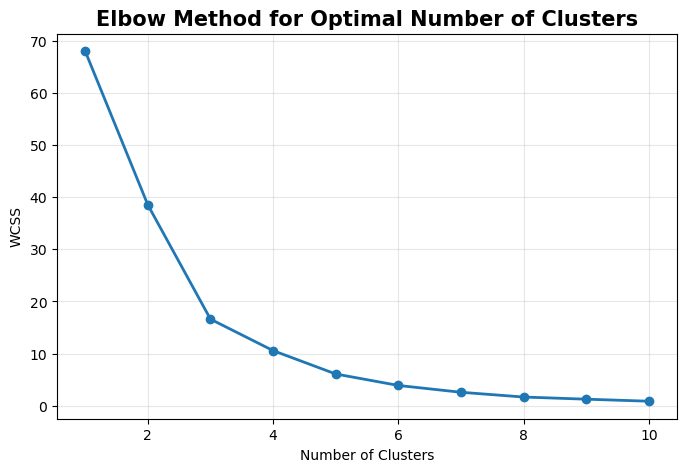

In [ ]:
### Elbow method
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title(
    "Elbow Method for Optimal Number of Clusters",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.show()

We can conlcude that our k value is "3"

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    silhouette_scores.append(score)

d:\anaconda3\envs\prompt_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\envs\prompt_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\envs\prompt_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\envs\prompt_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory le

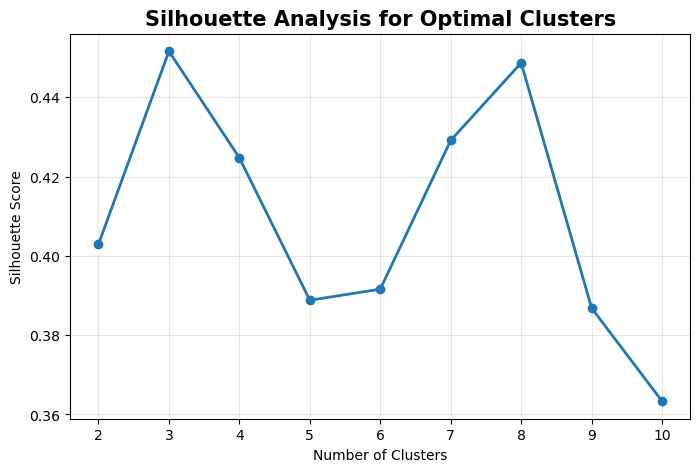

In [ ]:
### Silhoute curve
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title(
    "Silhouette Analysis for Optimal Clusters",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.show()

In [ ]:
### K values we get using silhouette
for k, score in zip(range(2,11), silhouette_scores):
    print(f"k = {k} --> {score:.4f}")

k = 2 --> 0.4029
k = 3 --> 0.4516
k = 4 --> 0.4248
k = 5 --> 0.3888
k = 6 --> 0.3916
k = 7 --> 0.4291
k = 8 --> 0.4487
k = 9 --> 0.3868
k = 10 --> 0.3633


### Selecting the Optimal Number of Clusters

The Elbow Method suggested that the optimal number of clusters lies around **3**, where the reduction in WCSS begins to level off. To validate this choice, Silhouette Analysis was performed.

The highest Silhouette Score (**0.4516**) was achieved for **k = 3**, indicating the best balance between cluster cohesion and separation. Therefore, **3 clusters** were selected for the final K-Means model.

In [ ]:
### KMeans training with final k value
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled_data)

# Save KMeans model
import pickle
with open("models/kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, f)
print("Saved KMeans model to models/kmeans.pkl")


d:\anaconda3\envs\prompt_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
### cluster
cluster_df.groupby("Cluster").mean(numeric_only=True)

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate
Cluster,,,,
0,146248.09400,2215.880212,5500.774391,479.729510
1,65326.20737,150.189900,1186.287889,67.421837
2,243671.10250,599.193752,3992.982732,27.323655


In [ ]:
### PCA
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

pca_data = pca.fit_transform(scaled_data)

cluster_df["PC1"] = pca_data[:,0]
cluster_df["PC2"] = pca_data[:,1]

# Save PCA model
import pickle
with open("models/pca.pkl", "wb") as f:
    pickle.dump(pca, f)
print("Saved PCA model to models/pca.pkl")


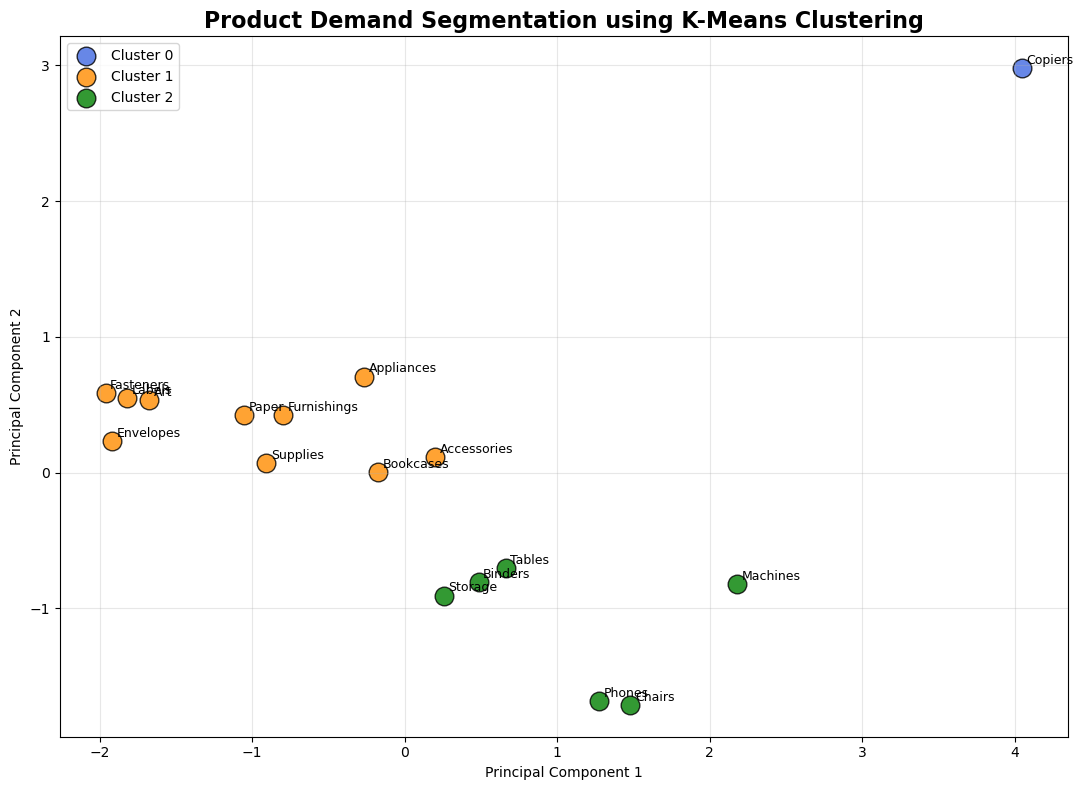

In [ ]:
### CLuster plot
plt.figure(figsize=(11,8))

colors = ["royalblue", "darkorange", "green"]

for cluster in sorted(cluster_df["Cluster"].unique()):

    temp = cluster_df[
        cluster_df["Cluster"] == cluster
    ]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=180,
        color=colors[cluster],
        edgecolor="black",
        alpha=0.8,
        label=f"Cluster {cluster}"
    )

# Annotate every sub-category
for index, row in cluster_df.iterrows():

    plt.text(
        row["PC1"] + 0.03,
        row["PC2"] + 0.03,
        index,
        fontsize=9
    )

plt.title(
    "Product Demand Segmentation using K-Means Clustering",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
### cluster table
cluster_names = {
    0: "Growing High-Value Products",
    1: "Low Volume, Stable Demand",
    2: "High Volume, Mature Products"
}

cluster_df["Demand Segment"] = (
    cluster_df["Cluster"]
    .map(cluster_names)
)

cluster_df

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate,Cluster,PC1,PC2,Demand Segment
Sub-Category,,,,,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961,1,0.200367,0.116729,"Low Volume, Stable Demand"
Appliances,104618.4030,227.926804,1821.621539,165.242912,1,-0.264248,0.707660,"Low Volume, Stable Demand"
Art,26705.4100,34.019631,330.488343,49.649531,1,-1.676784,0.535820,"Low Volume, Stable Demand"
Binders,200028.7850,134.067550,3848.223648,65.778638,2,0.484161,-0.805597,"High Volume, Mature Products"
Bookcases,113813.1987,503.598224,2220.405080,49.846598,1,-0.176589,0.003166,"Low Volume, Stable Demand"
Chairs,322822.7310,531.833165,4407.232960,20.954677,2,1.479554,-1.711393,"High Volume, Mature Products"
Copiers,146248.0940,2215.880212,5500.774391,479.729510,0,4.046026,2.979941,Growing High-Value Products
Envelopes,16128.0460,65.032444,228.218688,-12.121345,1,-1.920711,0.234844,"Low Volume, Stable Demand"
Fasteners,3001.9600,14.027850,48.742229,30.468364,1,-1.960973,0.583155,"Low Volume, Stable Demand"


In [ ]:
cluster_df.groupby("Demand Segment").size()

Demand Segment
Growing High-Value Products      1
High Volume, Mature Products     6
Low Volume, Stable Demand       10
dtype: int64

# Task 6: Product Demand Segmentation using K-Means Clustering

Sales data was aggregated at the product sub-category level using four features: **Total Sales, Average Order Value, Sales Volatility,** and **Year-over-Year Sales Growth Rate**. The features were standardized before applying K-Means clustering.

The optimal number of clusters was determined using both the **Elbow Method** and **Silhouette Analysis**. The Elbow Method indicated a clear bend at **k = 3**, while the highest Silhouette Score (**0.4516**) was also obtained for **3 clusters**. Therefore, **k = 3** was selected for the final model.

PCA (Principal Component Analysis) was used to reduce the feature space into two dimensions for visualization. The clustering resulted in three meaningful demand segments:

| Demand Segment | No. of Sub-Categories | Characteristics |
|---------------|----------------------:|-----------------|
| **Growing High-Value Products** | **1** | Very high average order value, highest sales growth, and high sales volatility. |
| **High Volume, Mature Products** | **6** | High total sales with established and consistent market demand. |
| **Low Volume, Stable Demand** | **10** | Lower sales volume with relatively stable and predictable demand. |

### Recommended Stocking Strategy

- **Growing High-Value Products:** Increase inventory gradually, monitor demand closely, and prioritize supplier availability to prevent stockouts.
- **High Volume, Mature Products:** Maintain consistently high inventory levels with regular replenishment to support steady demand.
- **Low Volume, Stable Demand:** Maintain lean inventory using demand-based replenishment to minimize holding costs while ensuring product availability.

Overall, the clustering analysis provides a data-driven approach for product segmentation, enabling more effective inventory planning and demand management based on product sales behavior.